# Bank Customer Churn

### In EDA part of this project, I will go through each and every steps of the EDA process to find pattern and meaningful insights.

## Import libraries:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

## Data Collection:

In [3]:
# bccd = bank customer churn data
bccd = pd.read_csv('./Data/Bank Customer Churn Prediction.csv')

## First look at the Data

In [4]:
bccd.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [346]:
bccd.shape

(10000, 12)

In [347]:
bccd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [348]:
bccd.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [349]:
bccd.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [350]:
bccd.tail()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


## Data Cleaning:

In [351]:
bccd.drop(columns=['customer_id'], inplace=True)

In [352]:
bccd.isnull().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [353]:
bccd.isna().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

There is no missing data in any of the column. So, no need to handle missing data.

In [354]:
bccd.duplicated().sum()

0

Same for duplicate data as well. There is no duplicate data in this dataset.

In [355]:
bccd.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

In [356]:
bccd.rename(columns={
    'products_number': 'no_of_product'
}, inplace=True)

In [357]:
bccd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   no_of_product     10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


column names are well structured and data type of the columns are correct. There is no need of change.

# EDA

In [358]:
categorical_cols = ['country', 'gender', 'no_of_product', 'credit_card', 'active_member']
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

## 1. Univariate Analysis

### Distribution of Numeric features(Histograms):

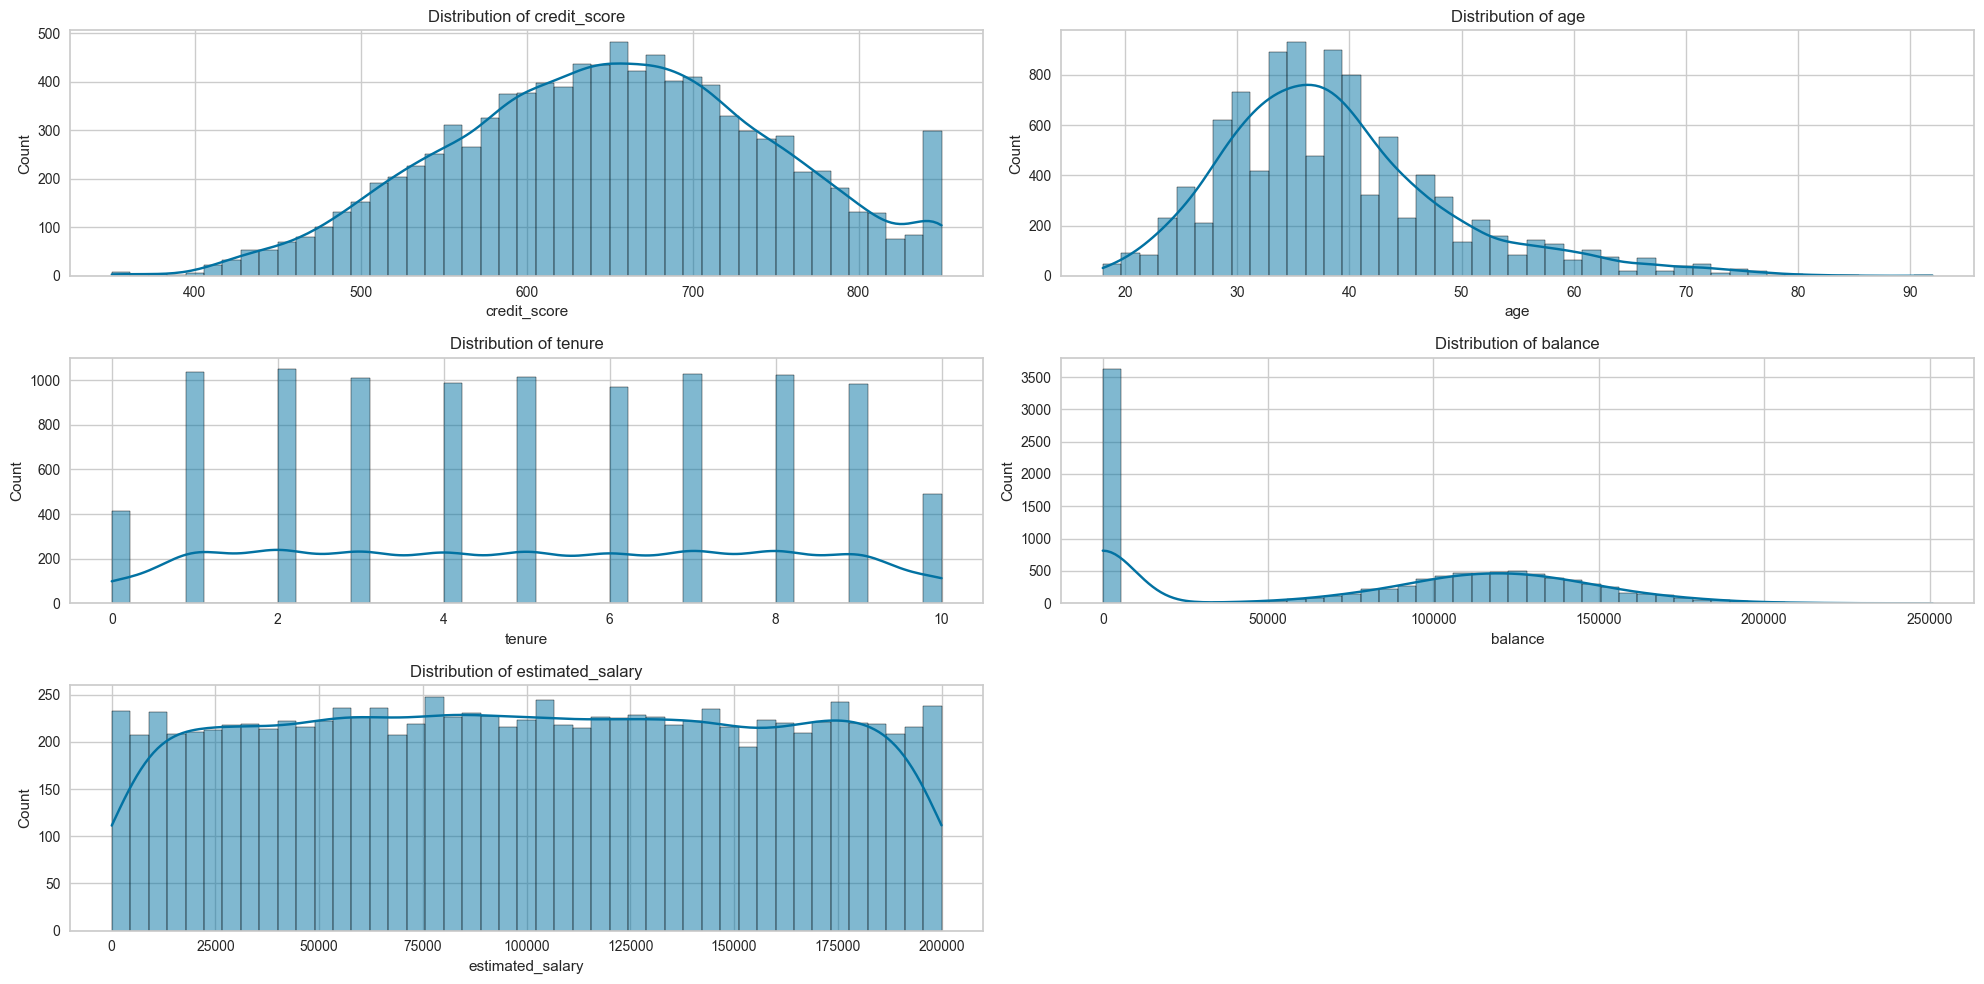

In [359]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(bccd[col], kde=True, bins=45)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In above histograms, we can see the typical value range, distribution of the data, skewness in the distributions for numeric features of the dataset.

- `credit_score` histogram is slightlt left-skewed.
- `age` histogram is right-skewed and it means there is low number of the customer with higher age in bank.
- `tenure` histogram suggest that all customers of the bank has the tenure between 0 to 10. Also, frequency of the customer whom tenure is 1 to 9 is almost same.
- `balance` histogram have huge spike at balance 0. More than 3500 customer has balance 0, which might indicate that those have some relation with churn. We will analyze it further.
- `estimated_salary` plot is showing no skewness and stable distribution of the value.

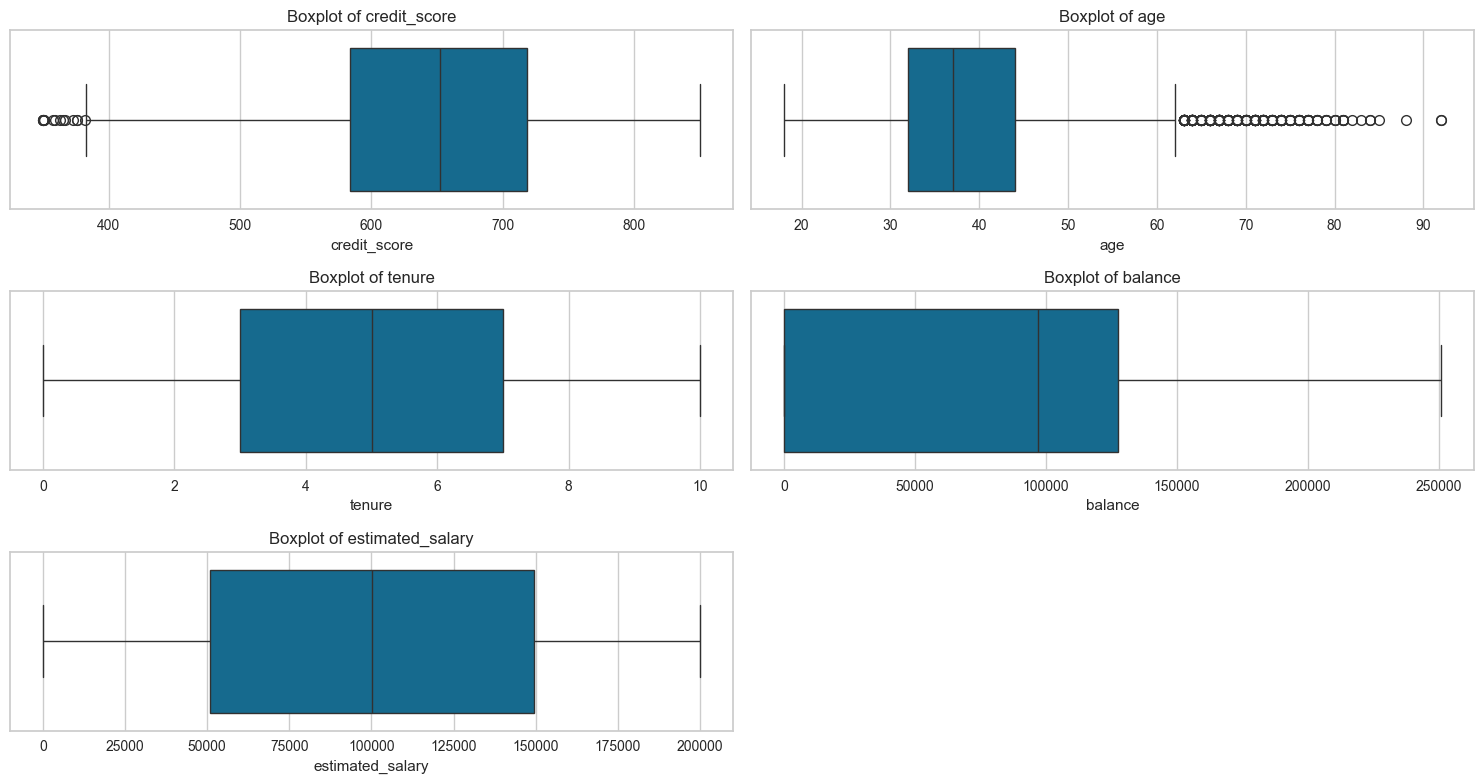

In [360]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=bccd[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

From above box plots, we can find the outliers in our dataset.

- credit score: It has some outlier before lower whisker. But this could be the meaningful data, because all outliers are very near to 400. As credit score could be the lower than 400. So, we have keep those values.
- age: Here in age, there are many outliers are visible after upper whisker. But last outlier is near to 90. It means it is a real data and it is not an outliers. It is a meaningful data and we should keep as it is.
- For tenure, balance and estimated salary, there are no outliers visible in their respective box plot.

### Count plots for Categorical features:

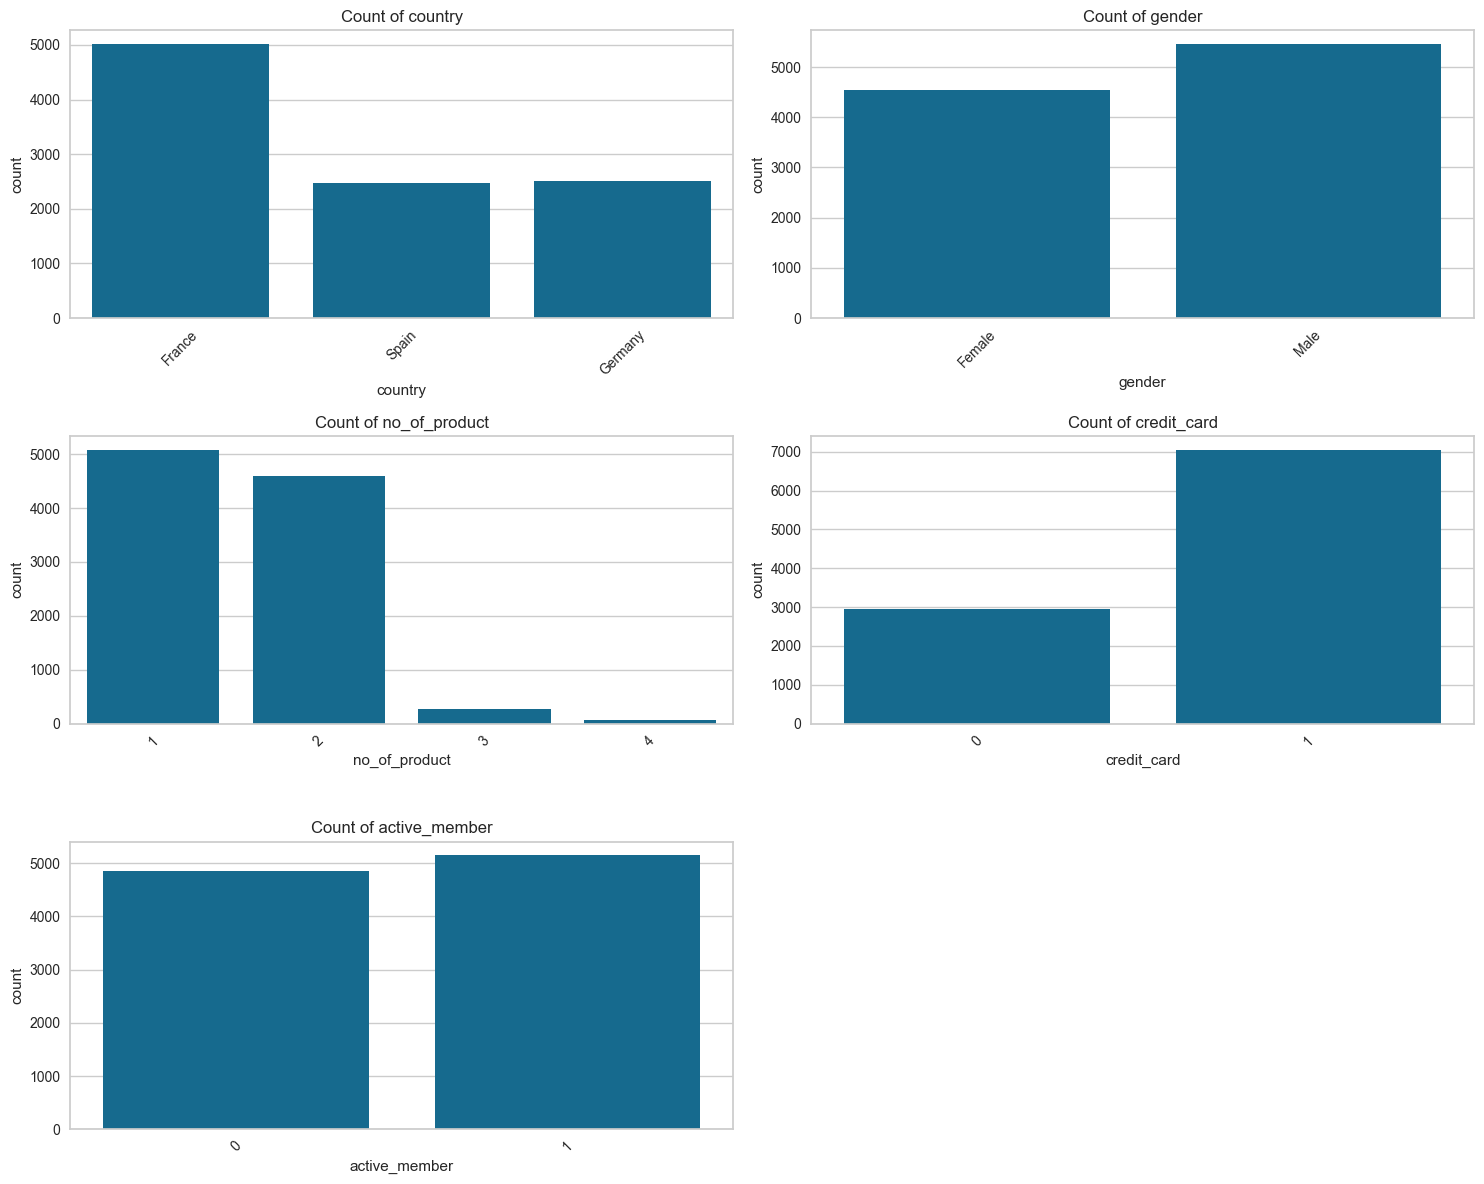

In [361]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=bccd, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From above count plots we can derive below important information.

- Most number of bank customer are from France. Although, there very slight difference in number for Spain and Germany.
- Most number of the customer is Male, where there is only difference of 1000 between and Male and Female customer.
- Almost large number of customers have only 1 or 2 products with the bank. Small number of customers have more than 2 products with the bank.
- More than 7000 customers have credit card with the bank.
- Almost 50% of the bank customer is inactive in the bank. There very slight difference between active and inactive customer of the bank.

### Distribution of the Target feature(Churn):

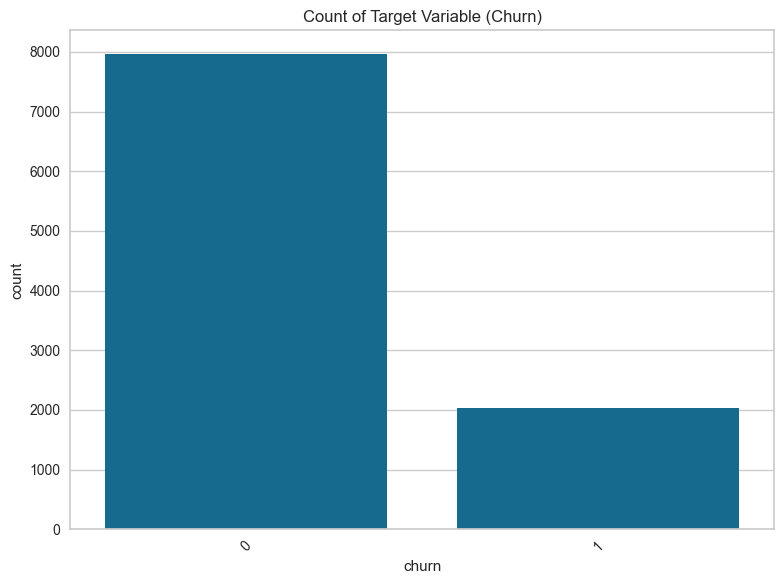

In [362]:
plt.figure(figsize=(8, 6))
sns.countplot(data=bccd, x='churn')
plt.title(f'Count of Target Variable (Churn)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

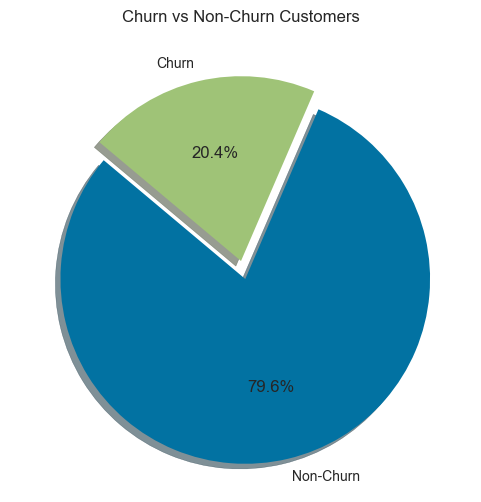

In [363]:
plt.figure(figsize=(6, 6))
plt.pie(bccd['churn'].value_counts(), labels=['Non-Churn', 'Churn'], explode=(0.1, 0), autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Churn vs Non-Churn Customers')
plt.ylabel('')
plt.show()

As we can see in pie chart, around 80% of the customer are still with bank and 20% bank customers leave the bank.

## 2. Bivariate Analysis

### Categorical features vs Churn

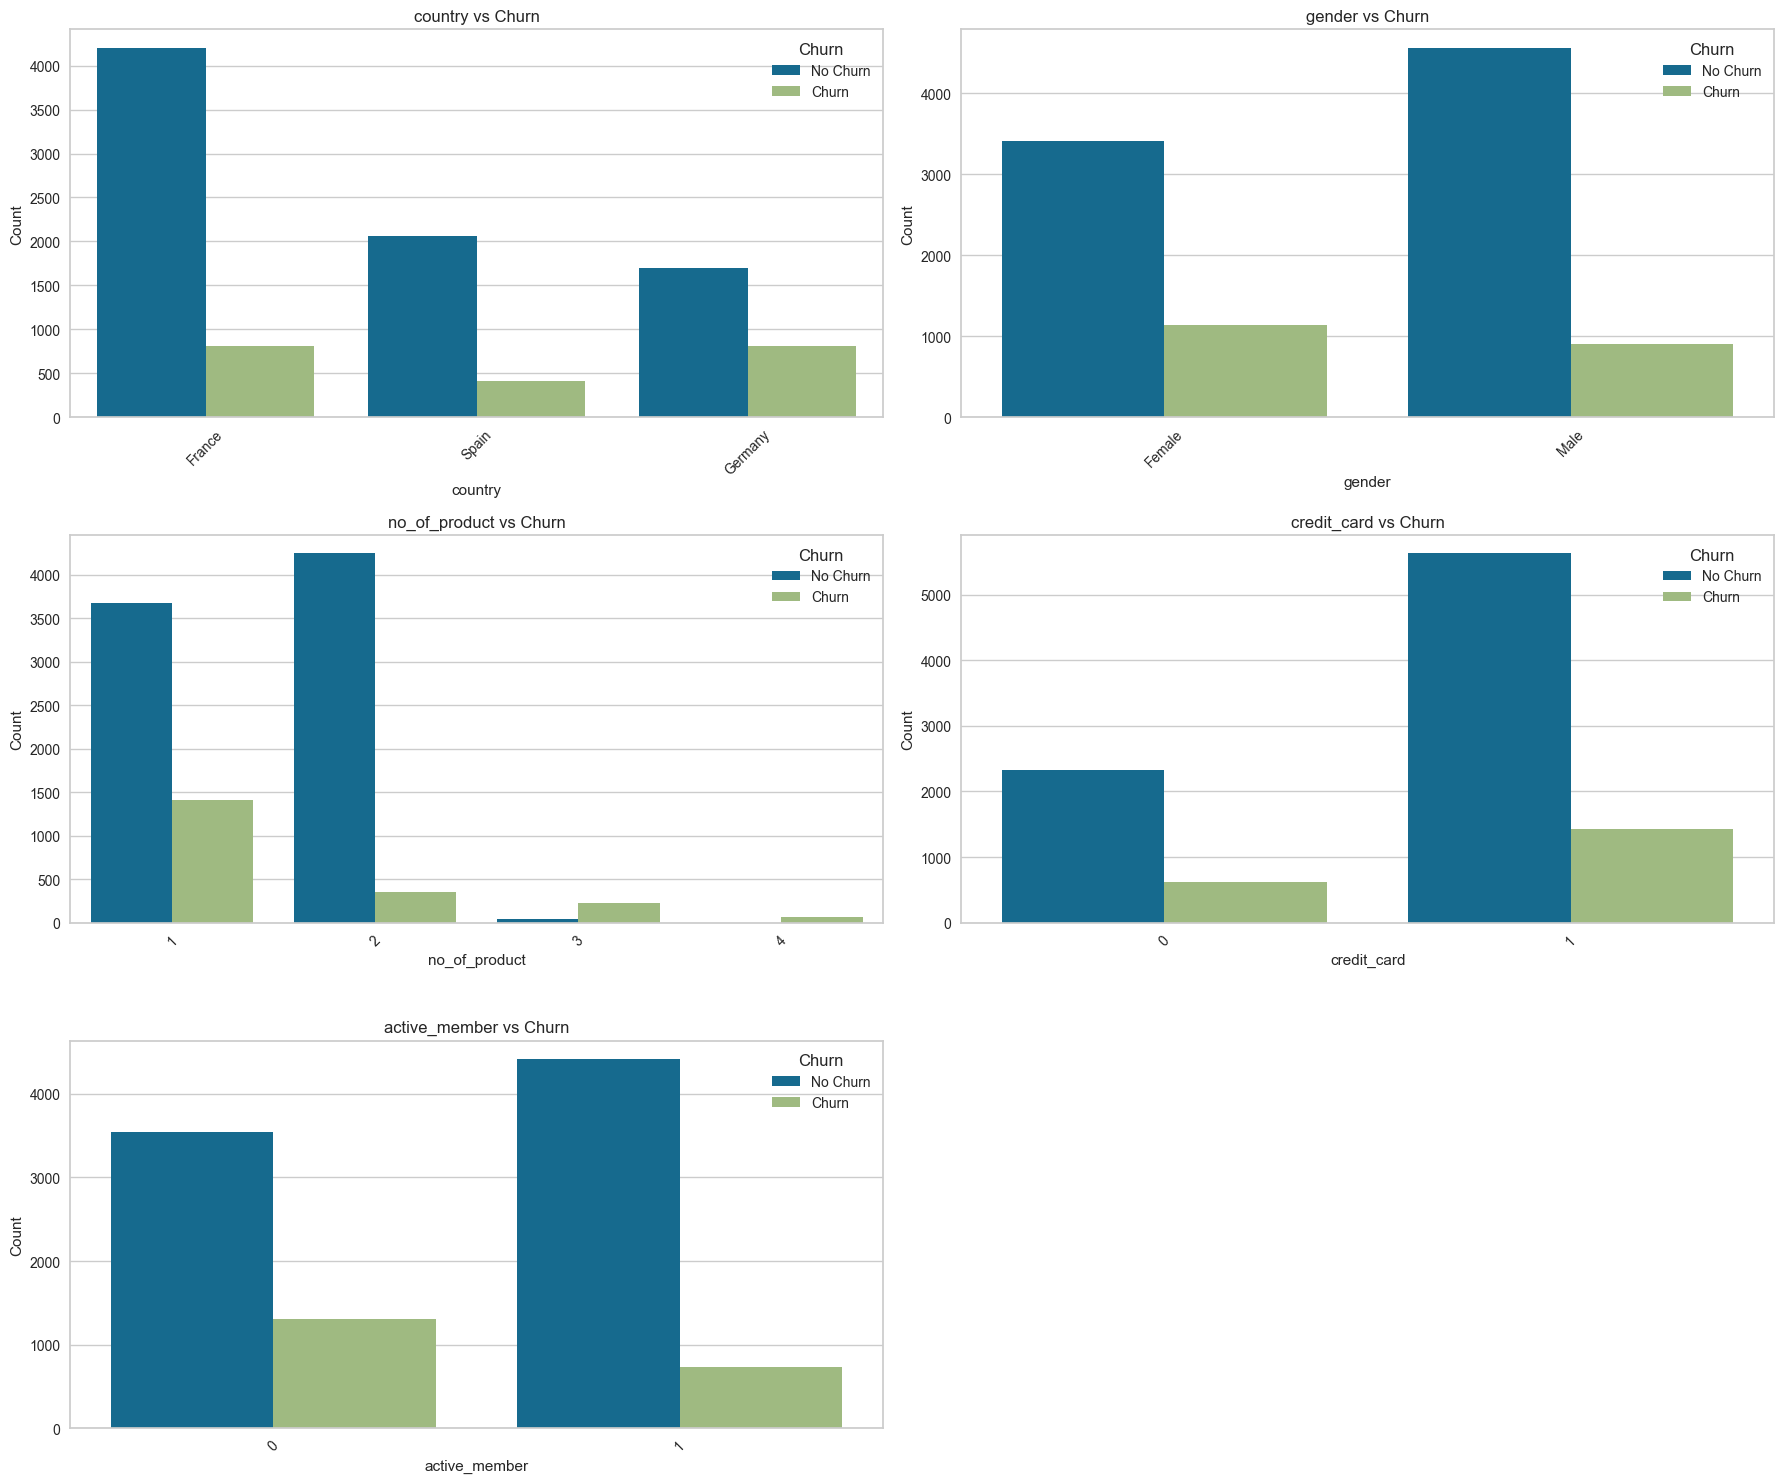

In [364]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    
    sns.countplot(data=bccd, x=col, hue='churn')
    
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Churn', labels=['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

##### Country:

From above grouped bar chart, we derive the information that `France` has the most number of the customers followed by `Spain` and `Germany`.

Despite having most number of customers, `France` has not most number of churn customer. It is `Germany` who has most number of the churn customer.

`Spain` has the least number of the churn customers.

##### Gender:

As we can see in the plot, there are most number of the customer in bank is `Male`. However, still churn rate is lower in `Male` compared to `Female` bank customer.

##### No. of Product:

As we can see this above bar chart, there is huge number of gap in customer that have credit card and not have credit card. There is large number of customer those does not have credit card.

The number is doubled for having credit card and not having. It is same for churn as well. Customer who have credit card has least chance to leave bank comapred to not having credit card.

##### Credit Card:

From bar chart, we come to know that there is large number of the customer are not active member of the bank.

Although, churn rate is also high if customer is Inactive.

So, we can analyse that if any customer is Inactive in the bank for long time, there is high chance to churn that customer.

##### Active member:

As we can see in the number of product vs churn bar chart, we can analyse that most of the customers have 1 or 2 products with the bank.

However, it is also visible that if customers have 1, 3, or 4 products with the bank, there is high chance of the churn of that customer compared to whom those have only 2 products with the bank.

### Numeric features vs Churn

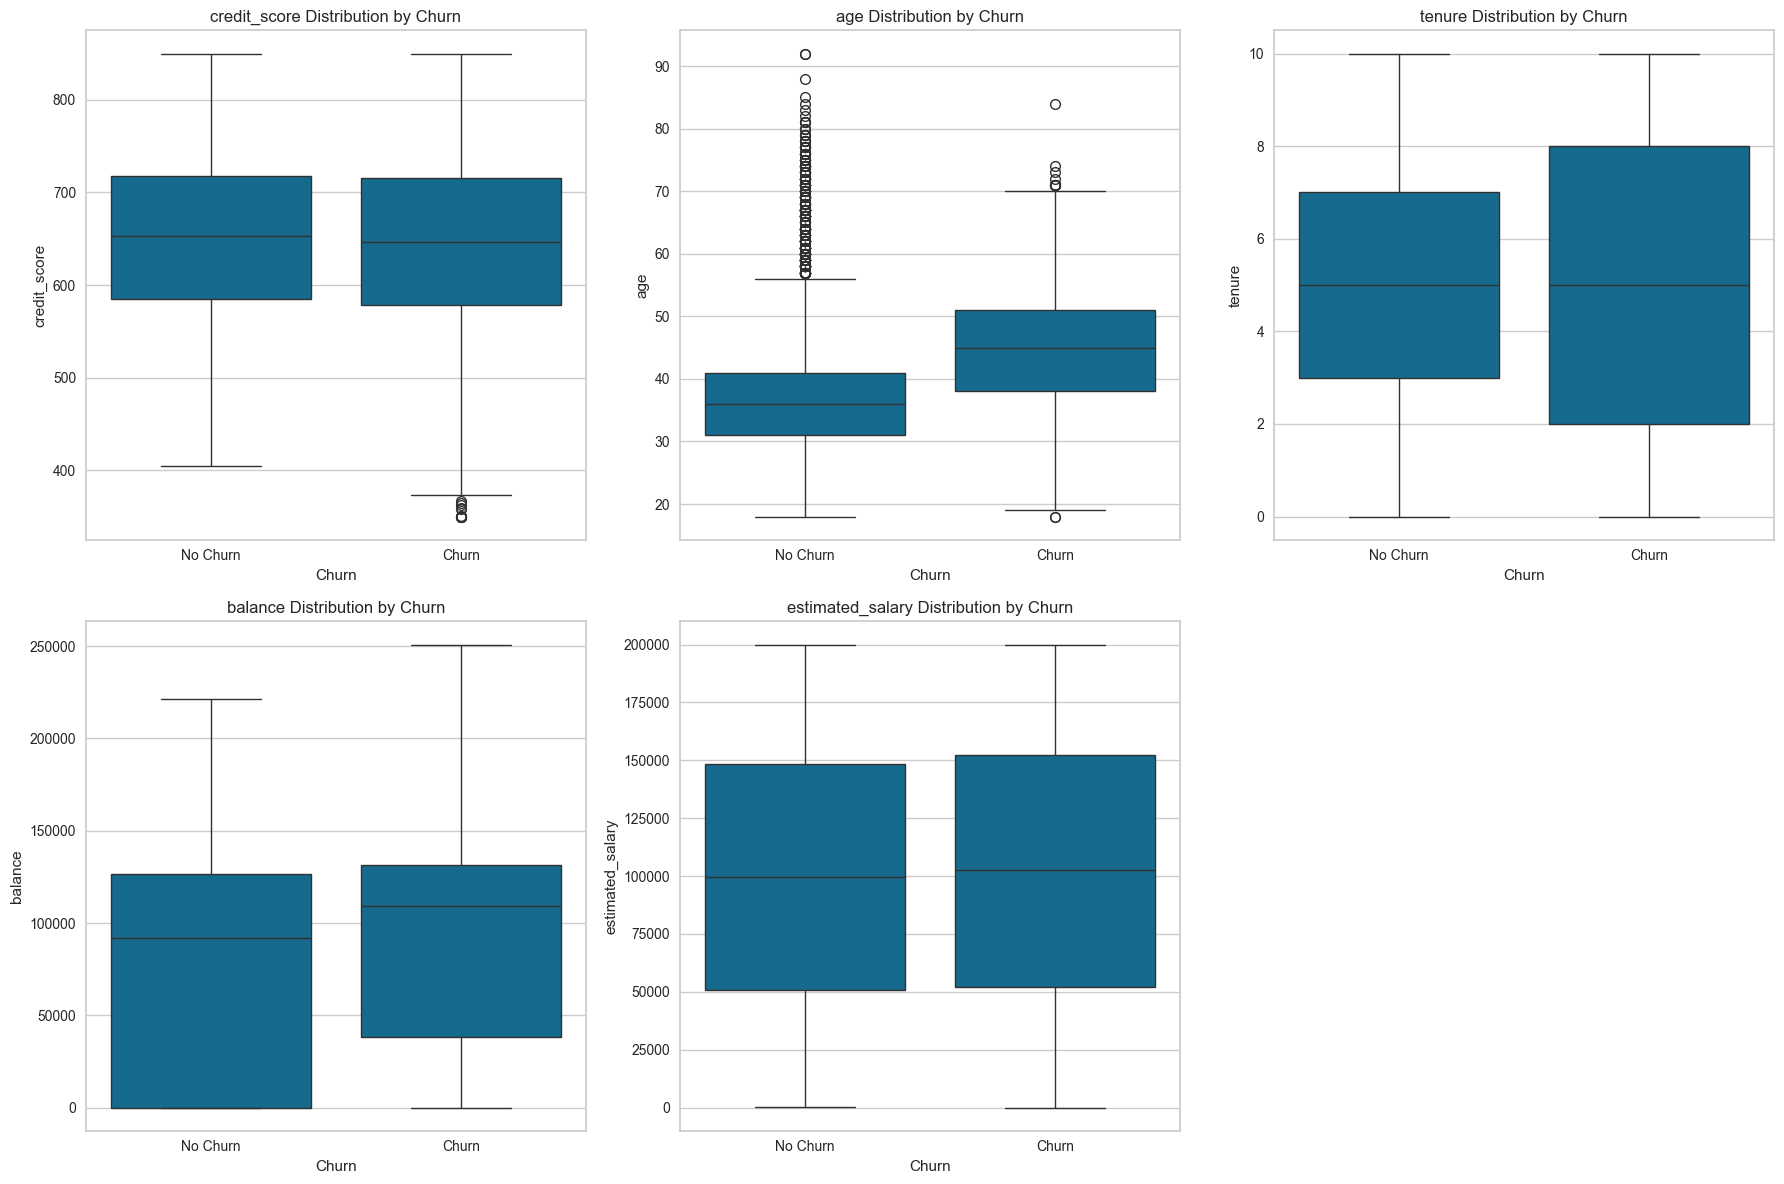

In [365]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    
    sns.boxplot(data=bccd, x='churn', y=col)
    plt.title(f'{col} Distribution by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.xticks([0, 1], ['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

#### Credit score:

- There are no much difference in both the box plots of credit score distribution by churn.
- Values are little more spread for churn customer.
- Also, there are some outliers down to lower whisker, but credit score might have that values. So, it is important value and we should not remove it.

#### Age:

- Median is higher for churn customer and data spread as well.
- But there are too many outliers for non churned customer box plot, but highest value is around to 90 and age can be the near 90.

#### Tenure:

- Median is same for both churn and non-churn customer.
- Data is more spread for churn customer as box size is high.

#### Balance:

- There many customer who have balance 0, and it is for non-churn customer.
- Median is high for churn customer compared to non-churn customer.

#### Estimated Salary:

- There is no much difference between 2 box plot.

# Feature Engineering:

### Let's do some feature engineering to help model to perform better to predict churn more accuretly.

In [366]:
bccd['balance_salary_ratio'] = bccd['balance'] / (bccd['estimated_salary'] + 1)

In [367]:
bccd['age_group'] = pd.cut(
    bccd['age'],
    bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '61-100']
)

In [368]:
bccd['tenure_group'] = pd.cut(
    bccd['tenure'],
    bins=[-1, 2, 5, 10],
    labels=['0-2', '3-5', '6-10']
)

In [369]:
bccd['credit_score_group'] = pd.cut(
    bccd['credit_score'],
    bins=[299, 579, 669, 739, 799, 850],
    labels=['poor', 'fair', 'good', 'very good', 'excellent']
)

In [370]:
bccd['has_balance'] = bccd['balance'].apply(lambda x: 1 if x > 0 else 0)

In [371]:
bccd['active_and_credit_card'] = bccd['active_member'] & bccd['credit_card']

In [ ]:
bccd['gender'] = bccd['gender'].apply(lambda x: 1 if x == 'Male' else 0)

# One-hot Encoding:

In [373]:
bccd_encoded = pd.get_dummies(bccd, columns=['country', 'credit_score_group', 'no_of_product', 'age_group', 'tenure_group'])

In [374]:
bccd_encoded.head(10)

,credit_score,gender,age,tenure,balance,credit_card,active_member,estimated_salary,churn,balance_salary_ratio,...,no_of_product_3,no_of_product_4,age_group_18-30,age_group_31-40,age_group_41-50,age_group_51-60,age_group_61-100,tenure_group_0-2,tenure_group_3-5,tenure_group_6-10
0,619,0,42,2,0.00,1,1,101348.88,1,0.000000,...,0,0,0,0,1,0,0,1,0,0
1,608,0,41,1,83807.86,0,1,112542.58,0,0.744670,...,0,0,0,0,1,0,0,1,0,0
2,502,0,42,8,159660.80,1,0,113931.57,1,1.401362,...,1,0,0,0,1,0,0,0,0,1
3,699,0,39,1,0.00,0,0,93826.63,0,0.000000,...,0,0,0,1,0,0,0,1,0,0
4,850,0,43,2,125510.82,1,1,79084.10,0,1.587035,...,0,0,0,0,1,0,0,1,0,0
5,645,1,44,8,113755.78,1,0,149756.71,1,0.759599,...,0,0,0,0,1,0,0,0,0,1
6,822,1,50,7,0.00,1,1,10062.80,0,0.000000,...,0,0,0,0,1,0,0,0,0,1
7,376,0,29,4,115046.74,1,0,119346.88,1,0.963961,...,0,1,1,0,0,0,0,0,1,0
8,501,1,44,4,142051.07,0,1,74940.50,0,1.895493,...,0,0,0,0,1,0,0,0,1,0
9,684,1,27,2,134603.88,1,1,71725.73,0,1.876621,...,0,0,1,0,0,0,0,1,0,0


# Correlation Matrix:

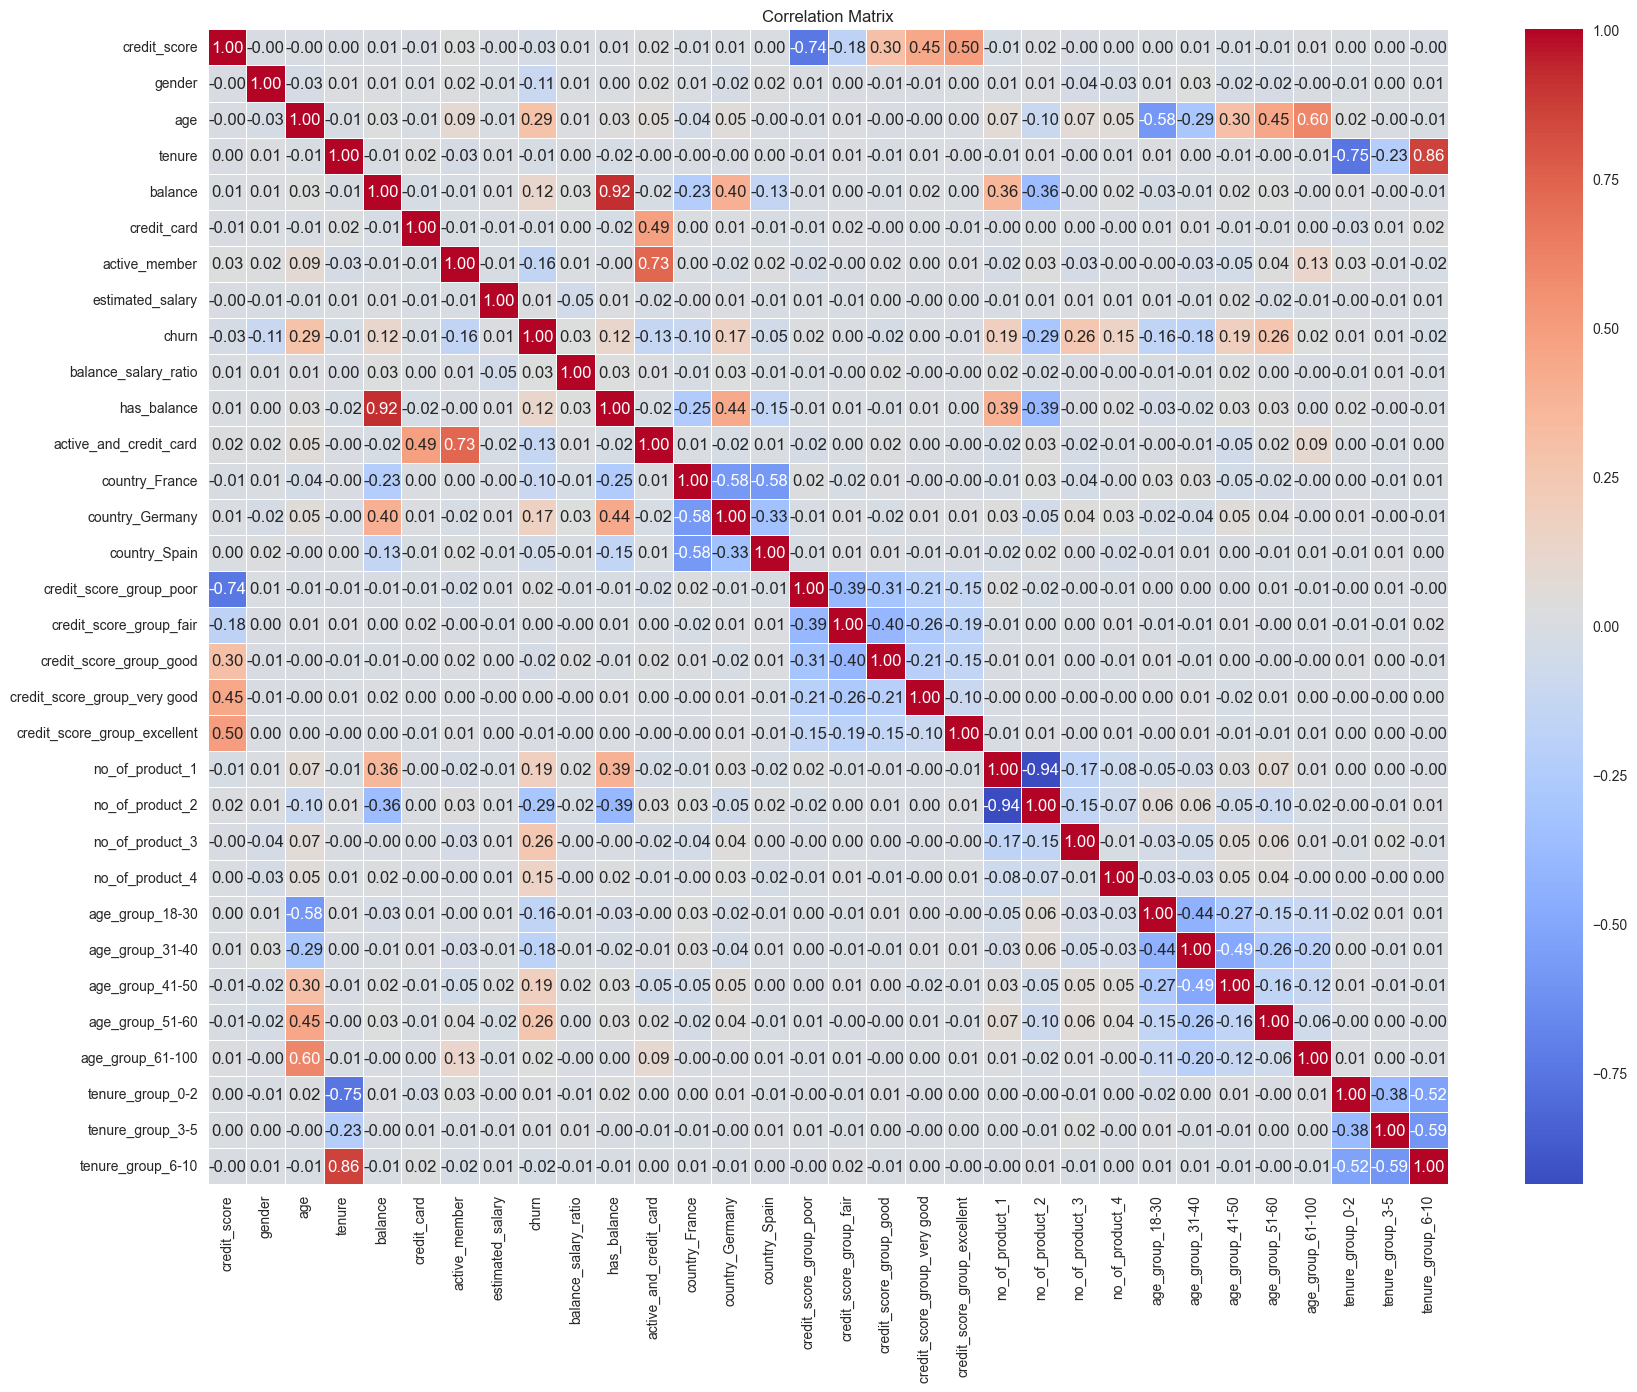

In [375]:
corr_matrix = bccd_encoded.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

#### After converting all our data into numeric format, here is a correlation matrix. Here we can see that how each features are corelate with other features. Value 1 means perfectly corelated and as value decrease relation between the features decrease.

# Data Preparation:

In [376]:
scaler = MinMaxScaler()

scaling_features = ['credit_score', 'age', 'balance', 'estimated_salary']

bccd_encoded[scaling_features] = scaler.fit_transform(bccd_encoded[scaling_features])

In [377]:
bccd_encoded.head(10)

,credit_score,gender,age,tenure,balance,credit_card,active_member,estimated_salary,churn,balance_salary_ratio,...,no_of_product_3,no_of_product_4,age_group_18-30,age_group_31-40,age_group_41-50,age_group_51-60,age_group_61-100,tenure_group_0-2,tenure_group_3-5,tenure_group_6-10
0,0.538,0,0.324324,2,0.000000,1,1,0.506735,1,0.000000,...,0,0,0,0,1,0,0,1,0,0
1,0.516,0,0.310811,1,0.334031,0,1,0.562709,0,0.744670,...,0,0,0,0,1,0,0,1,0,0
2,0.304,0,0.324324,8,0.636357,1,0,0.569654,1,1.401362,...,1,0,0,0,1,0,0,0,0,1
3,0.698,0,0.283784,1,0.000000,0,0,0.469120,0,0.000000,...,0,0,0,1,0,0,0,1,0,0
4,1.000,0,0.337838,2,0.500246,1,1,0.395400,0,1.587035,...,0,0,0,0,1,0,0,1,0,0
5,0.590,1,0.351351,8,0.453394,1,0,0.748797,1,0.759599,...,0,0,0,0,1,0,0,0,0,1
6,0.944,1,0.432432,7,0.000000,1,1,0.050261,0,0.000000,...,0,0,0,0,1,0,0,0,0,1
7,0.052,0,0.148649,4,0.458540,1,0,0.596733,1,0.963961,...,0,1,1,0,0,0,0,0,1,0
8,0.302,1,0.351351,4,0.566170,0,1,0.374680,0,1.895493,...,0,0,0,0,1,0,0,0,1,0
9,0.668,1,0.121622,2,0.536488,1,1,0.358605,0,1.876621,...,0,0,1,0,0,0,0,1,0,0


In [378]:
X = bccd_encoded.drop(columns=['churn'])
y = bccd_encoded['churn']

In [379]:
def split_data(X, y):
    return train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=435
    )

In [380]:
X_train, X_test, y_train, y_test = split_data(X, y)

# Model Development:

In [381]:
def gb_model_creation(X_train_data, X_test_data, y_train_data, y_test_data):
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(X_train_data, y_train_data)
    y_pred_data = model.predict(X_test_data)
    return model, y_pred_data

In [382]:
def model_evalution(y_test_data, y_pred_data):
    print("Accuracy:", accuracy_score(y_test_data, y_pred_data))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test_data, y_pred_data))
    print("\nClassification Report:\n", classification_report(y_test_data, y_pred_data))

In [383]:
gb_basic_model, y_pred = gb_model_creation(X_train, X_test, y_train, y_test)

model_evalution(y_test, y_pred)

Accuracy: 0.8556666666666667

Confusion Matrix:
 [[2309  103]
 [ 330  258]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91      2412
           1       0.71      0.44      0.54       588

    accuracy                           0.86      3000
   macro avg       0.79      0.70      0.73      3000
weighted avg       0.84      0.86      0.84      3000



#### Here, we have created basic Gradient Boosting Classifier model. After training and testing the model, we got above accuracy and other matrix.

# Feature Importance

#### Now, let's do feature importance to improve model's accuracy.

In [384]:
def feat_importances(model, X_data):
    imps = model.feature_importances_
    return pd.Series(imps * 100, index=X_data.columns.to_list()).sort_values(ascending=False)

#### multiplying the importance with 100 for better visualization and comparison.

<AxesSubplot: >

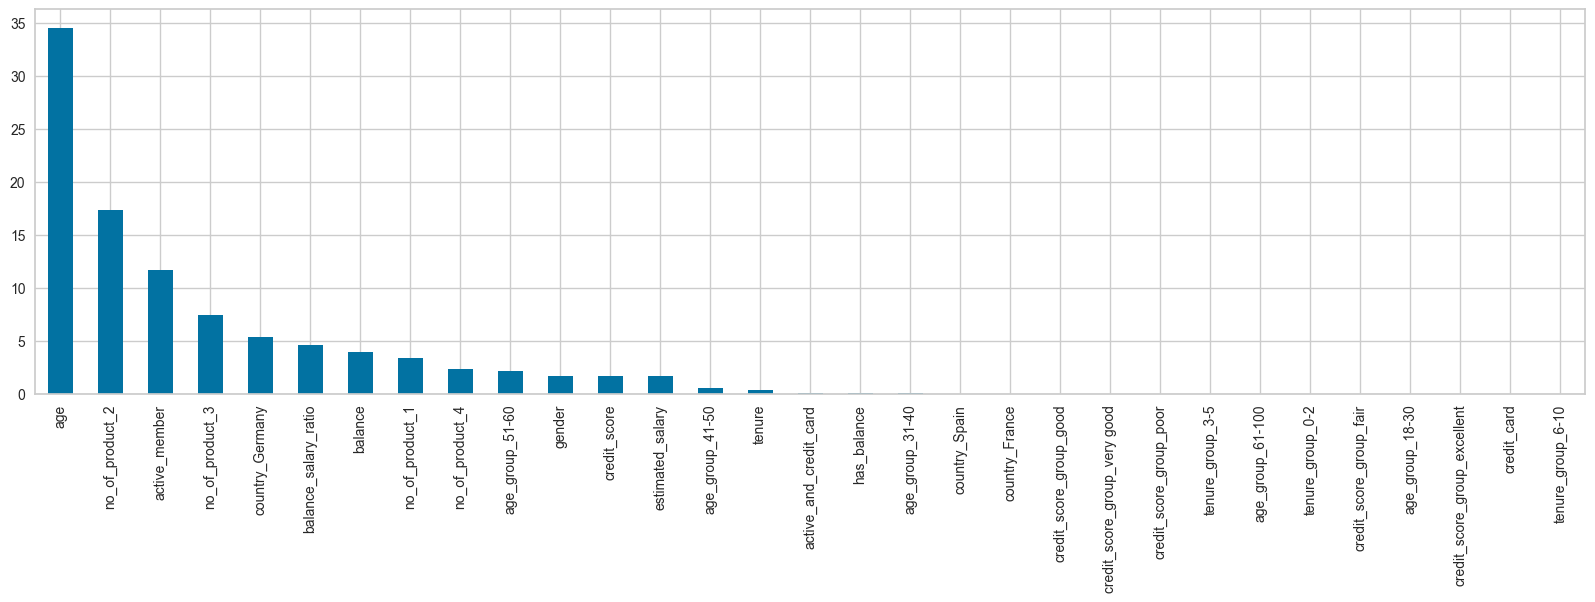

In [385]:
feat_imps = feat_importances(gb_basic_model, X)
feat_imps.plot(kind='bar', figsize=(20, 5))

#### First, let's remove features with 0 importance.

In [386]:
# feat_importances[feat_importances > 0]
new_feats_1 = feat_imps[feat_imps > 0].index.to_list()
new_feats_1

['age',
 'no_of_product_2',
 'active_member',
 'no_of_product_3',
 'country_Germany',
 'balance_salary_ratio',
 'balance',
 'no_of_product_1',
 'no_of_product_4',
 'age_group_51-60',
 'gender',
 'credit_score',
 'estimated_salary',
 'age_group_41-50',
 'tenure',
 'active_and_credit_card',
 'has_balance',
 'age_group_31-40',
 'country_Spain',
 'country_France',
 'credit_score_group_good',
 'credit_score_group_very good',
 'credit_score_group_poor',
 'tenure_group_3-5',
 'age_group_61-100']

## Re-run the Model(2):

In [387]:
X_2 = bccd_encoded[new_feats_1]
X_train_2, X_test_2, y_train_2, y_test_2 = split_data(X_2, y)

In [388]:
model_2, y_pred_2 = gb_model_creation(X_train_2, X_test_2, y_train_2, y_test_2)

model_evalution(y_test_2, y_pred_2)

Accuracy: 0.8556666666666667

Confusion Matrix:
 [[2309  103]
 [ 330  258]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91      2412
           1       0.71      0.44      0.54       588

    accuracy                           0.86      3000
   macro avg       0.79      0.70      0.73      3000
weighted avg       0.84      0.86      0.84      3000



#### After removing some features, we re-run the model. But it seems like model is not improved much. Let's see the new feature importance.

age                             34.561287
no_of_product_2                 17.332562
active_member                   11.760202
no_of_product_3                  7.465086
country_Germany                  5.358875
balance_salary_ratio             4.652013
balance                          4.162798
no_of_product_1                  3.449368
no_of_product_4                  2.382985
age_group_51-60                  2.179374
gender                           1.751881
credit_score                     1.743517
estimated_salary                 1.664511
age_group_41-50                  0.637908
tenure                           0.418977
active_and_credit_card           0.169951
age_group_31-40                  0.085248
country_Spain                    0.064617
country_France                   0.047701
credit_score_group_good          0.037847
credit_score_group_very good     0.033698
credit_score_group_poor          0.029345
tenure_group_3-5                 0.007675
age_group_61-100                 0

<AxesSubplot: >

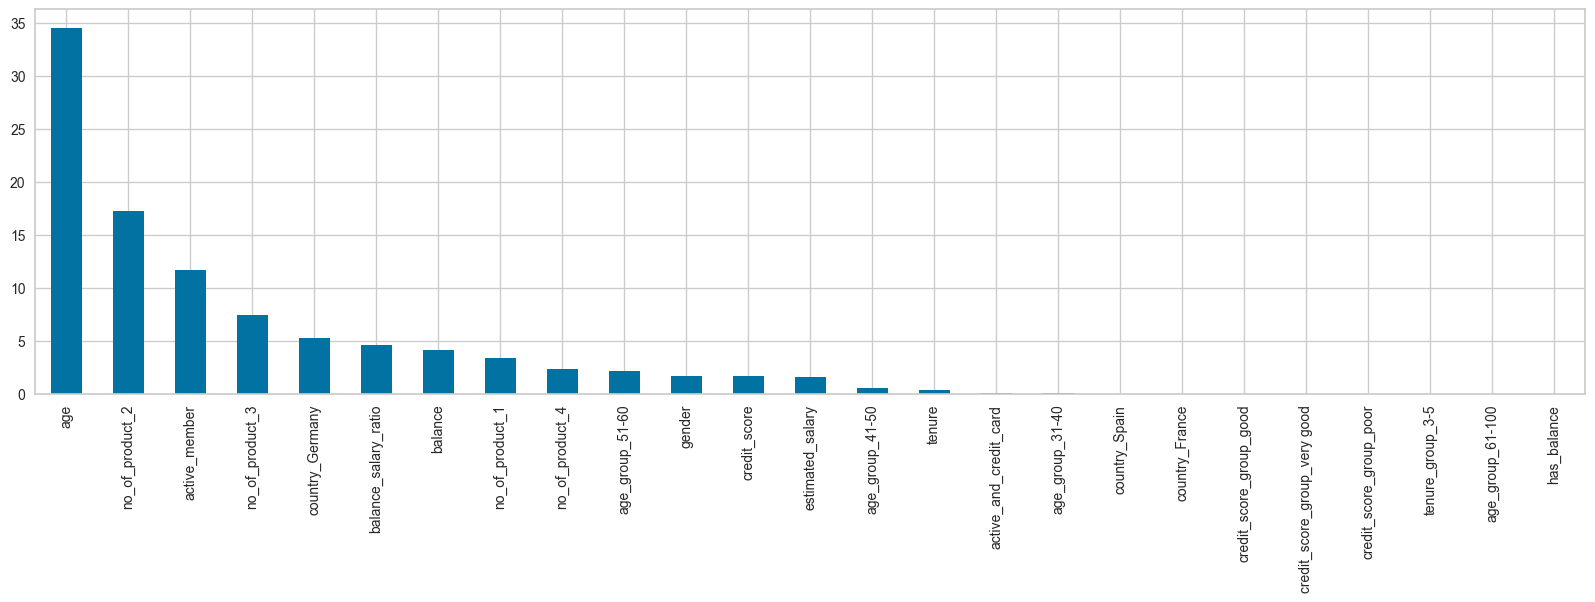

In [389]:
feat_imps_2 = feat_importances(model_2, X_2)
print(feat_imps_2)
feat_imps_2.plot(kind='bar', figsize=(20, 5))

#### As we can see, we have again some more features with near to 0 importance. Let's remove those and analyze model's performace.

In [390]:
new_feats_2 = feat_imps_2[feat_imps_2 > 1].index.to_list()
new_feats_2

['age',
 'no_of_product_2',
 'active_member',
 'no_of_product_3',
 'country_Germany',
 'balance_salary_ratio',
 'balance',
 'no_of_product_1',
 'no_of_product_4',
 'age_group_51-60',
 'gender',
 'credit_score',
 'estimated_salary']

## Re-run the Model(3):

In [391]:
X_3 = bccd_encoded[new_feats_2]
X_train_3, X_test_3, y_train_3, y_test_3 = split_data(X_3, y)

In [392]:
model_3, y_pred_3 = gb_model_creation(X_train_3, X_test_3, y_train_3, y_test_3)

model_evalution(y_test_3, y_pred_3)

Accuracy: 0.8576666666666667

Confusion Matrix:
 [[2310  102]
 [ 325  263]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      2412
           1       0.72      0.45      0.55       588

    accuracy                           0.86      3000
   macro avg       0.80      0.70      0.73      3000
weighted avg       0.85      0.86      0.84      3000



#### If we know, last time our model's accuracy was 0.8556 but it is 0.8576, it means feature importance really helps to improve model's performance. It is very small improvement but it means alot in model development.

age                     35.309142
no_of_product_2         17.319594
active_member           11.875410
no_of_product_3          7.503698
country_Germany          5.130131
balance                  4.803270
balance_salary_ratio     4.632157
no_of_product_1          3.508527
no_of_product_4          2.376983
age_group_51-60          2.149884
credit_score             1.917371
gender                   1.757628
estimated_salary         1.716204
dtype: float64


<AxesSubplot: >

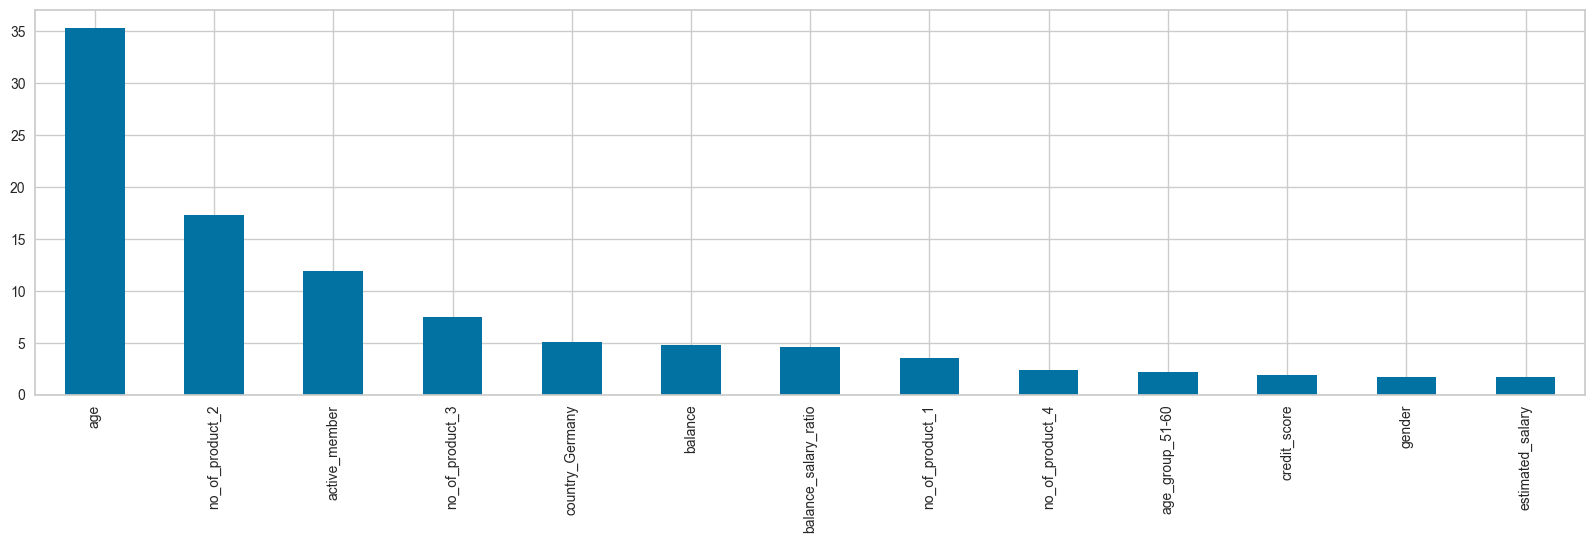

In [393]:
feat_imps_3 = feat_importances(model_3, X_3)
print(feat_imps_3)
feat_imps_3.plot(kind='bar', figsize=(20, 5))

#### Let's remove last 5 features and check model's performace for one last time.

In [394]:
new_feats_3 = feat_imps_3[feat_imps_3 > 3].index.to_list()
new_feats_3

['age',
 'no_of_product_2',
 'active_member',
 'no_of_product_3',
 'country_Germany',
 'balance',
 'balance_salary_ratio',
 'no_of_product_1']

## Re-run the Model(4):

In [395]:
X_4 = bccd_encoded[new_feats_3]
X_train_4, X_test_4, y_train_4, y_test_4 = split_data(X_4, y)

In [396]:
model_4, y_pred_4 = gb_model_creation(X_train_4, X_test_4, y_train_4, y_test_4)

model_evalution(y_test_4, y_pred_4)

Accuracy: 0.8586666666666667

Confusion Matrix:
 [[2306  106]
 [ 318  270]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      2412
           1       0.72      0.46      0.56       588

    accuracy                           0.86      3000
   macro avg       0.80      0.71      0.74      3000
weighted avg       0.85      0.86      0.85      3000



#### Our model's accuracy increase from 0.8576 to 0.8586

#### Along with feature impotance, we can tune hyperparameters of the model to improve model.

# Hyperparameter Tuning:

In [397]:
gbc = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy after tuning:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Accuracy after tuning: 0.858

Confusion Matrix:
 [[2299  113]
 [ 313  275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92      2412
           1       0.71      0.47      0.56       588

    accuracy                           0.86      3000
   macro avg       0.79      0.71      0.74      3000
weighted avg       0.85      0.86      0.85      3000



#### After hyperparameter tuning, we get our best model and best performance for model.

- True Negative = 2299
- False Positive = 113
- False Negative = 313
- True Positive = 275

#### 